In [1]:
from matplotlib.pyplot import title
%load_ext autoreload
%autoreload 2
%matplotlib widget

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import experiment.ocean.helpers as mod
import cyl_lvm as clvm
from scipy import stats

In [2]:
PROJECT_ROOT = mod.find_project_root()
DATA_DIR = PROJECT_ROOT / "data" / "ndbc"
DATA_PATH = DATA_DIR / "ocean_data.csv"

prepared = mod.prepare_data(csv_path=DATA_PATH, shuffle=True, random_state=157)

In [3]:
df = prepared["frame"]
train_frame = prepared["train_frame"]
test_frame = prepared["test_frame"]
x_train = prepared["x_train"]
x_train_lin, x_train_dir = x_train[:, :3], x_train[:, 3:]
x_test = prepared["x_test"]
x_test_lin, x_test_dir = x_test[:, :3], x_test[:, 3:]

split_summary = pd.DataFrame([
    {
        "split": "train",
        "n": len(train_frame),
        "start": prepared["train_time_range"][0],
        "end": prepared["train_time_range"][1],
    },
    {
        "split": "test",
        "n": len(test_frame),
        "start": prepared["test_time_range"][0],
        "end": prepared["test_time_range"][1],
    },
])
split_summary

,split,n,start,end
0,train,149792,2000-01-01 00:00:00+00:00,2022-12-31 23:40:00+00:00
1,test,37449,2000-01-01 02:00:00+00:00,2022-12-31 19:40:00+00:00


In [4]:
feature_names = [*prepared["linear_features"], prepared["direction_feature"]]
model_feature_names = list(prepared["feature_names"])
feature_names

['wvht', 'apd', 'wspd', 'mwd']

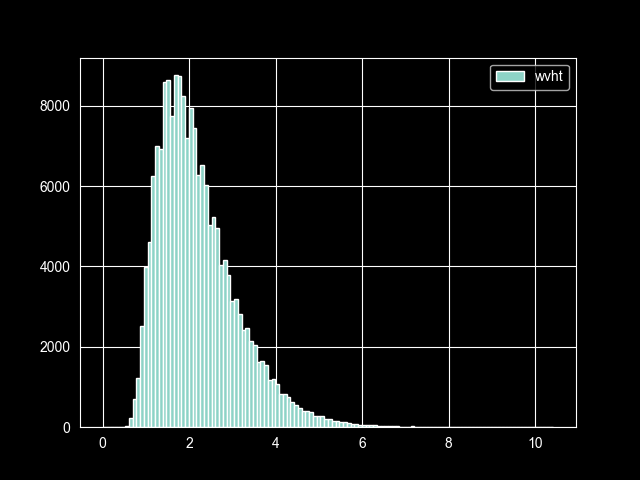

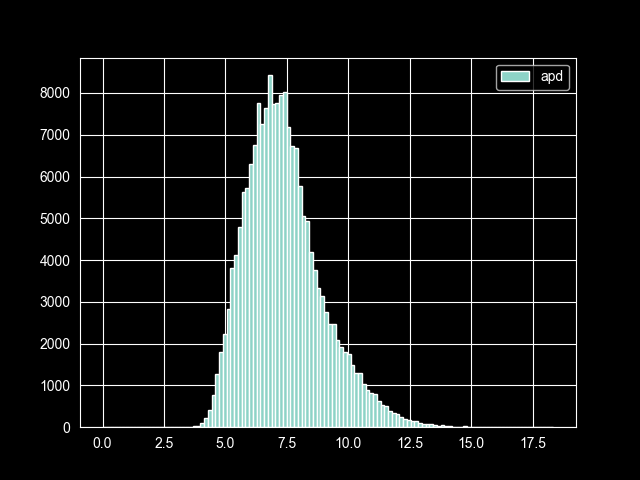

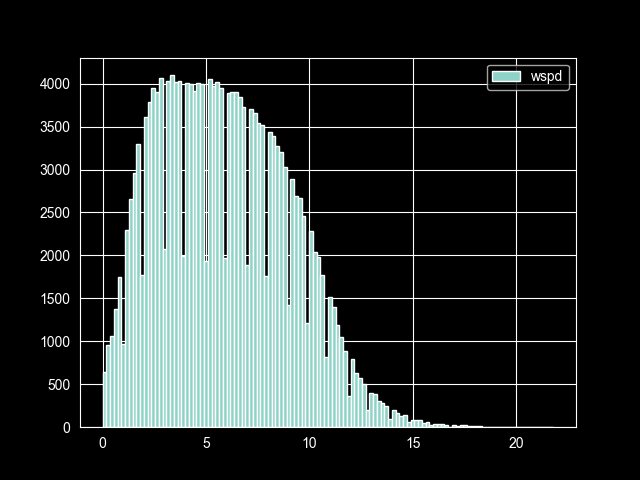

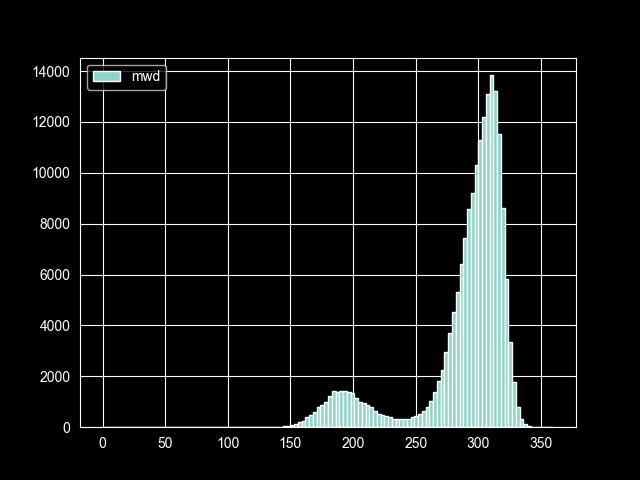

In [5]:
for feature in feature_names:
    df[feature].hist(bins=120, legend=feature)
    plt.show()
    plt.close()

In [6]:
x_train.shape, x_test.shape

((149792, 5), (37449, 5))

In [7]:
prepared["transformer"].lambdas_

array([-0.56829108, -0.33828112,  0.55402264])

### Training

In [8]:
n_restarts = 5
k_grid = (1, 2, 3, 4, 5, 6)
l_grid = (1, 2, 3, 4)

In [9]:
indcyl_grid_dict = mod.grid_search_ind_cylindrical_mixture(
    x_train,
    d_gauss=3,
    d_vmf=2,
    k_grid=k_grid,
    n_restarts=n_restarts,
    init="k-means",
    random_state=1,
)

Finished run 1/30 (3.3%) | k=1 | restart=0 | BIC=1.40327e+06 | success
Finished run 2/30 (6.7%) | k=1 | restart=1 | BIC=1.40327e+06 | success
Finished run 3/30 (10.0%) | k=1 | restart=2 | BIC=1.40327e+06 | success
Finished run 4/30 (13.3%) | k=1 | restart=3 | BIC=1.40327e+06 | success
Finished run 5/30 (16.7%) | k=1 | restart=4 | BIC=1.40327e+06 | success
Finished run 6/30 (20.0%) | k=2 | restart=0 | BIC=1.24933e+06 | success
Finished run 7/30 (23.3%) | k=2 | restart=1 | BIC=1.24933e+06 | success
Finished run 8/30 (26.7%) | k=2 | restart=2 | BIC=1.24933e+06 | success
Finished run 9/30 (30.0%) | k=2 | restart=3 | BIC=1.24933e+06 | success
Finished run 10/30 (33.3%) | k=2 | restart=4 | BIC=1.24933e+06 | success
Finished run 11/30 (36.7%) | k=3 | restart=0 | BIC=1.18488e+06 | success
Finished run 12/30 (40.0%) | k=3 | restart=1 | BIC=1.18488e+06 | success
Finished run 13/30 (43.3%) | k=3 | restart=2 | BIC=1.18495e+06 | success
Finished run 14/30 (46.7%) | k=3 | restart=3 | BIC=1.18488e+06

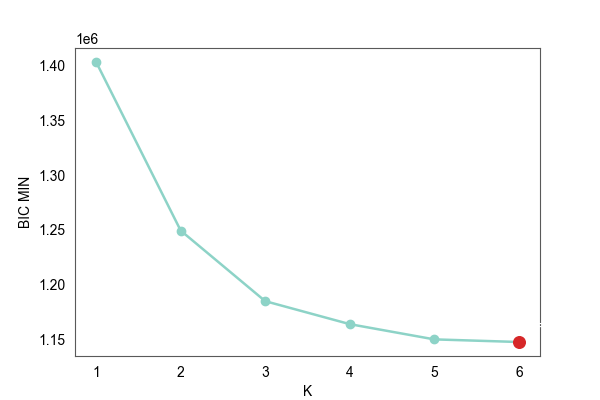

In [23]:
fig, ax = mod.plot_cylindrical_grid_search_bic(
    indcyl_grid_dict,
    title="",
    save_path="noaa_grid_indcylmix.pdf",
)

In [11]:
cyl_grid_dict = mod.grid_search_cylindrical_mixture(
    x_train,
    d_gauss=3,
    d_vmf=2,
    k_grid=k_grid,
    n_restarts=n_restarts,
    init="k-means",
    random_state=1,
)

Finished run 1/30 (3.3%) | k=1 | restart=0 | BIC=1.36413e+06 | success
Finished run 2/30 (6.7%) | k=1 | restart=1 | BIC=1.36413e+06 | success
Finished run 3/30 (10.0%) | k=1 | restart=2 | BIC=1.36413e+06 | success
Finished run 4/30 (13.3%) | k=1 | restart=3 | BIC=1.36413e+06 | success
Finished run 5/30 (16.7%) | k=1 | restart=4 | BIC=1.36413e+06 | success
Finished run 6/30 (20.0%) | k=2 | restart=0 | BIC=1.22262e+06 | success
Finished run 7/30 (23.3%) | k=2 | restart=1 | BIC=1.22262e+06 | success
Finished run 8/30 (26.7%) | k=2 | restart=2 | BIC=1.22262e+06 | success
Finished run 9/30 (30.0%) | k=2 | restart=3 | BIC=1.22262e+06 | success
Finished run 10/30 (33.3%) | k=2 | restart=4 | BIC=1.22262e+06 | success
Finished run 11/30 (36.7%) | k=3 | restart=0 | BIC=1.16754e+06 | success
Finished run 12/30 (40.0%) | k=3 | restart=1 | BIC=1.16754e+06 | success
Finished run 13/30 (43.3%) | k=3 | restart=2 | BIC=1.16763e+06 | success
Finished run 14/30 (46.7%) | k=3 | restart=3 | BIC=1.16753e+06

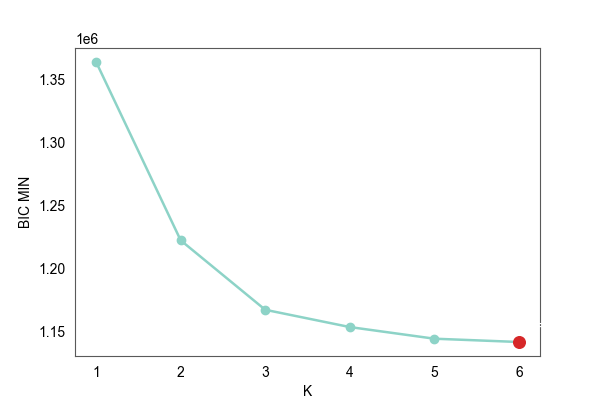

In [24]:
fig, ax = mod.plot_cylindrical_grid_search_bic(
    cyl_grid_dict,
    title="",
    save_path="noaa_grid_cylmix.pdf",
)

In [13]:
tl_gauss_grid_dict = mod.grid_search_two_layer_mixture_gaussian_vmf(
    x_train_lin,
    x_train_dir,
    k_grid=k_grid,
    l_grid=l_grid,
    n_restarts=n_restarts,
    init_layer1="k-means",
    init_layer2="k-means",
    random_state=1,
)

Finished run 1/120 (0.8%) | k=1 l=1 | restart=0 | BIC=1.40327e+06 | success
Finished run 2/120 (1.7%) | k=1 l=1 | restart=1 | BIC=1.40327e+06 | success
Finished run 3/120 (2.5%) | k=1 l=1 | restart=2 | BIC=1.40327e+06 | success
Finished run 4/120 (3.3%) | k=1 l=1 | restart=3 | BIC=1.40327e+06 | success
Finished run 5/120 (4.2%) | k=1 l=1 | restart=4 | BIC=1.40327e+06 | success
Finished run 6/120 (5.0%) | k=1 l=2 | restart=0 | BIC=1.27648e+06 | success
Finished run 7/120 (5.8%) | k=1 l=2 | restart=1 | BIC=1.27648e+06 | success
Finished run 8/120 (6.7%) | k=1 l=2 | restart=2 | BIC=1.27648e+06 | success
Finished run 9/120 (7.5%) | k=1 l=2 | restart=3 | BIC=1.27648e+06 | success
Finished run 10/120 (8.3%) | k=1 l=2 | restart=4 | BIC=1.27648e+06 | success
Finished run 11/120 (9.2%) | k=1 l=3 | restart=0 | BIC=1.26564e+06 | success
Finished run 12/120 (10.0%) | k=1 l=3 | restart=1 | BIC=1.26564e+06 | success
Finished run 13/120 (10.8%) | k=1 l=3 | restart=2 | BIC=1.26564e+06 | success
Finish

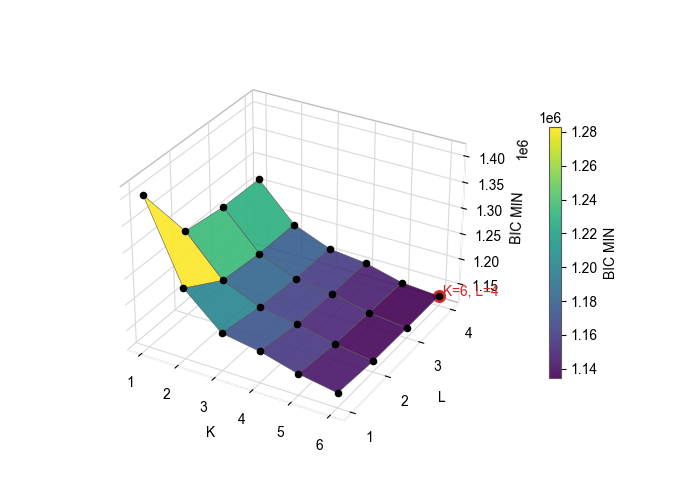

In [25]:
fig, ax = mod.plot_two_layer_grid_search_bic_surface(
    tl_gauss_grid_dict,
    title="",
    save_path="noaa_grid_twolayer_gauss.pdf",
)

In [15]:
tl_vmf_grid_dict = mod.grid_search_two_layer_vmf_gaussian(
    x_train_dir,
    x_train_lin,
    k_grid=k_grid,
    l_grid=l_grid,
    n_restarts=n_restarts,
    init_layer1="k-means",
    init_layer2="k-means",
    random_state=1,
)

Finished run 1/120 (0.8%) | k=1 l=1 | restart=0 | BIC=1.40327e+06 | success
Finished run 2/120 (1.7%) | k=1 l=1 | restart=1 | BIC=1.40327e+06 | success
Finished run 3/120 (2.5%) | k=1 l=1 | restart=2 | BIC=1.40327e+06 | success
Finished run 4/120 (3.3%) | k=1 l=1 | restart=3 | BIC=1.40327e+06 | success
Finished run 5/120 (4.2%) | k=1 l=1 | restart=4 | BIC=1.40327e+06 | success
Finished run 6/120 (5.0%) | k=1 l=2 | restart=0 | BIC=1.34507e+06 | success
Finished run 7/120 (5.8%) | k=1 l=2 | restart=1 | BIC=1.34506e+06 | success
Finished run 8/120 (6.7%) | k=1 l=2 | restart=2 | BIC=1.34506e+06 | success
Finished run 9/120 (7.5%) | k=1 l=2 | restart=3 | BIC=1.34507e+06 | success
Finished run 10/120 (8.3%) | k=1 l=2 | restart=4 | BIC=1.34507e+06 | success
Finished run 11/120 (9.2%) | k=1 l=3 | restart=0 | BIC=1.33726e+06 | success
Finished run 12/120 (10.0%) | k=1 l=3 | restart=1 | BIC=1.33725e+06 | success
Finished run 13/120 (10.8%) | k=1 l=3 | restart=2 | BIC=1.34136e+06 | success
Finish

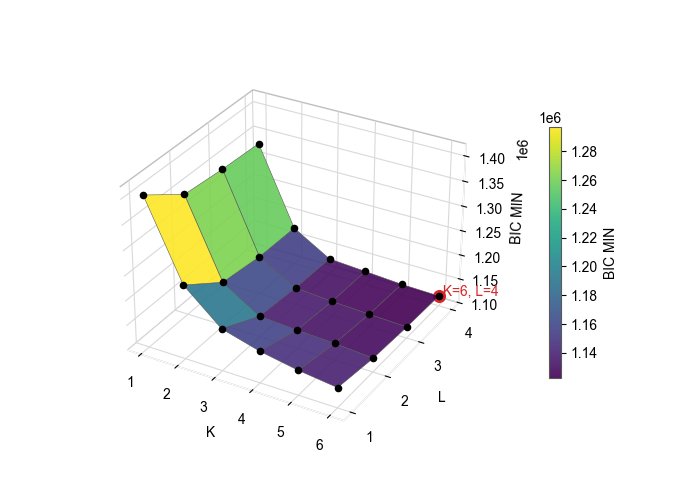

In [26]:
fig, ax = mod.plot_two_layer_grid_search_bic_surface(
    tl_vmf_grid_dict,
    title="",
    save_path="noaa_grid_twolayer_vmf.pdf",
)